# Signal Evaluation Framework  

---
### Sections
1. Setup & Configuration  
2. Data Loading  
3. Signal Generation  
4. Core Helpers  
5. Compute Base Metrics
5. Walk-Forward Optimization
6. Combinatorial Purging + Embargo Cross-Validation
7. Probability of Backtest Overfitting
8. False Discovery Rate
7. Expected Shortfall Curves + Drawdown Duration Distribution
8. Research Quality Score With Gates



# Setup & Configuration

In [37]:
# ==============================================================================
# CELL 1: SETUP & CONFIGURATION (USER ADJUSTABLE)
# ==============================================================================
import os
import sys
import warnings
import itertools
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

TRAIN_START = "2004-11-18"
TRAIN_END = "2018-12-31"
TEST_START = "2019-01-01"
TEST_END = "2023-12-31"

SIGNAL_MODULE_DIR = "/content/drive/My Drive/Prometheus/First cycle/"

# Trading frictions
TRANSACTION_COST_BPS = 5.0
SLIPPAGE_BPS = 2.0

# Statistical controls
NW_LAGS = 5
ES_ALPHAS =[0.01, 0.025, 0.05, 0.10]
N_CPCV_FOLDS = 10
CPCV_TEST_BLOCKS = 2
EMBARGO_DAYS = 10
MIN_OBS_PER_SPLIT = 120
WFO_TRAIN_YEARS = 5
WFO_TEST_YEARS = 1

# Research quality gates
GATE_MIN_TEST_SHARPE = 0.40
GATE_MAX_TURNOVER = 0.40
GATE_MIN_DSR = 0.50
GATE_MAX_PBO = 0.60

print("✅ Cell 1: Setup complete. Proceed to Data Loading.")

✅ Cell 1: Setup complete. Proceed to Data Loading.


# Data Loading

In [38]:
# ==============================================================================
# CELL 2: DATA LOADING
# ==============================================================================
from google.colab import drive
if not os.path.exists("/content/drive/My Drive"):
    drive.mount("/content/drive")

sys.path.insert(0, SIGNAL_MODULE_DIR)

from cycle_1_signals import (
        load_data, build_seasonal_signals, build_volume_signals, build_breadth_base_signals,
        build_macro_breadth_signals, build_rates_fx_signals, build_asym_vol_signals,
        build_fibonacci_signals, build_efficiency_noise_signals, build_overnight_intraday_signals,
        build_gap_signals, build_volatility_momentum_signals, build_autocorrelation_signals,
        build_low_rv_signals, build_high_vix_signals, build_bear_signals, build_low_vix_signals)

full_df = load_data().copy()
full_df["Ret"] = full_df["Close"].pct_change().fillna(0)
train_mask = (full_df.index >= TRAIN_START) & (full_df.index <= TRAIN_END)
test_mask = (full_df.index >= TEST_START) & (full_df.index <= TEST_END)

print(f"Data Loaded! Train rows: {train_mask.sum()} | Test rows: {test_mask.sum()}")

Data Loaded! Train rows: 3553 | Test rows: 1258


# Signal Generation

In [39]:
# ==============================================================================
# CELL 3: SIGNAL GENERATION (USER-ADJUSTABLE)
# ==============================================================================
print("Generating signals…")
sea_sigs = build_seasonal_signals(full_df)
vol_sigs = build_volume_signals(full_df)
brb_sigs = build_breadth_base_signals(full_df)
mac_sigs = build_macro_breadth_signals(full_df)
rfx_sigs = build_rates_fx_signals(full_df)
asym_sigs = build_asym_vol_signals(full_df)
fib_sigs = build_fibonacci_signals(full_df)
eff_sigs = build_efficiency_noise_signals(full_df)
oni_sigs = build_overnight_intraday_signals(full_df)
gap_sigs = build_gap_signals(full_df)
vmo_sigs = build_volatility_momentum_signals(full_df)
aco_sigs = build_autocorrelation_signals(full_df)
lrv_sigs = build_low_rv_signals(full_df)
hvix_sigs = build_high_vix_signals(full_df)
bear_sigs = build_bear_signals(full_df)
lvix_sigs = build_low_vix_signals(full_df)

ALL_SIGS = {
    **sea_sigs, **vol_sigs, **brb_sigs, **mac_sigs,
    **rfx_sigs, **asym_sigs, **fib_sigs, **eff_sigs,
    **oni_sigs, **gap_sigs, **vmo_sigs, **aco_sigs,
    **lrv_sigs, **hvix_sigs, **bear_sigs, **lvix_sigs}

SIG_GROUPS = {
    "Seasonal": list(sea_sigs.keys()),
    "Volume": list(vol_sigs.keys()),
    "BreadthBase": list(brb_sigs.keys()),
    "Macro": list(mac_sigs.keys()),
    "Rates/FX": list(rfx_sigs.keys()),
    "AsymVol": list(asym_sigs.keys()),
    "Fibonacci": list(fib_sigs.keys()),
    "Efficiency": list(eff_sigs.keys()),
    "OvernightID": list(oni_sigs.keys()),
    "Gaps": list(gap_sigs.keys()),
    "VolMomentum": list(vmo_sigs.keys()),
    "AutoCorr": list(aco_sigs.keys()),
    "LowRV": list(lrv_sigs.keys()),
    "HighVIX": list(hvix_sigs.keys()),
    "Bear": list(bear_sigs.keys()),
    "LowVIX": list(lvix_sigs.keys())}

BH = pd.Series(1.0, index=full_df.index, name="Buy & Hold")

print(f"\n✅  {len(ALL_SIGS)} signals generated")
for grp, keys in SIG_GROUPS.items():
    print(f'   {grp:15s}: {keys}')

Generating signals…

✅  116 signals generated
   Seasonal       : ['Sea_01_TOM_VolExp', 'Sea_02_Jan_MeanRev', 'Sea_03_Dec_VolContr', 'Sea_04_RobustM_BBSqz', 'Sea_05_PreHol_Trend100']
   Volume         : ['Vol_01_VROC_ClimaxFade', 'Vol_02_ZThresh_Scale', 'Vol_03_PVTrend_Gap', 'Vol_04_ZMom_ExtremeRSI', 'Vol_05_CMF_Accel']
   BreadthBase    : ['BrB_01_Intraday_Mom', 'BrB_02_Thrust_BTI', 'BrB_03_MA_Align_Mom', 'BrB_04_VolWeight_Rev', 'BrB_05_ShortTerm_Rev']
   Macro          : ['Mac_01_GDX_TrendMiner', 'Mac_02_Ratio_Panic', 'Mac_03_CompBreadth', 'Mac_04_EcoDays', 'Mac_05_PurePanic', 'Mac_06_ADL_LongOnly', 'Mac_07_Corr_SPXBear', 'Mac_08_TechOutperf', 'Mac_09_SmBreadthBear', 'Mac_10_PropAdv_Ribbon', 'Mac_11_W2Rev_VVIX', 'Mac_12_CuU2_GLDBull', 'Mac_13_FiltB2_NoFri', 'Mac_14_RR10_EMA3_Long', 'Mac_15_RR50_ScaleU2']
   Rates/FX       : ['RFX_01_U10_RSI_Div_Long', 'RFX_02_U10_RealRates', 'RFX_03_U10_YieldMom', 'RFX_04_U2_YieldRev_Asym', 'RFX_05_U2_ContYield_EMA', 'RFX_06_U2_RatioTrend_Skew', 'RFX

# Core Helpers

sanitize_signal:
$$
s_t=\mathrm{clip}(\tilde{s}_t,-1,1),\qquad
\tilde{s}_t=
\begin{cases}
\text{sig}_t,& \text{if observed}\\
0,& \text{if missing}
\end{cases}
$$

compute_returns:
$$
r^{\text{gross}}_t=s_t\,r^{\text{mkt}}_t,\qquad
\text{turnover}_t=\lvert s_t-s_{t-1}\rvert
$$
$$
c=\frac{\text{tc\_bps}+\text{slip\_bps}}{10{,}000},\qquad
\text{cost}_t=c\cdot \text{turnover}_t,\qquad
r^{\text{net}}_t=r^{\text{gross}}_t-\text{cost}_t
$$

max_drawdown:
$$
DD_t=\frac{W_t}{\max_{u\le t}W_u}-1,\qquad
\text{MaxDD}=\min_t DD_t
$$

newey_west_se_mean:
$$
x_t=r_t-\bar r,\qquad
\gamma_0=\frac{1}{n}\sum_{t=1}^{n}x_t^2,\qquad
\gamma_k=\frac{1}{n}\sum_{t=k+1}^{n}x_t\,x_{t-k}
$$
$$
w_k=1-\frac{k}{L+1},\qquad
\widehat{\sigma}^2_{LR}=\gamma_0+2\sum_{k=1}^{L}w_k\,\gamma_k,\qquad
SE(\bar r)=\sqrt{\frac{\widehat{\sigma}^2_{LR}}{n}}
$$

sharpe_stats:
$$
\mu=\bar r,\quad \sigma=\mathrm{sd}(r),\quad n=|r|,\qquad
SR_d=\frac{\mu}{\sigma},\qquad
SR_{\text{ann}}=\sqrt{252}\,SR_d
$$
$$
t_\mu=\frac{\mu}{SE(\mu)},\qquad
p_\mu=2\left(1-\Phi\left(|t_\mu|\right)\right)
$$
$$
SE(SR_d)=\sqrt{\frac{1+\tfrac{1}{2}SR_d^2}{n-1}},\qquad
t_{SR}=\frac{SR_d}{SE(SR_d)},\qquad
p_{SR}=2\left(1-\Phi\left(|t_{SR}|\right)\right)
$$

deflated_sharpe_ratio (Bailey & López de Prado, 2014):
$$
z_1=\Phi^{-1}\left(1-\frac{1}{N}\right),\qquad
z_2=\Phi^{-1}\left(1-\frac{e^{-1}}{N}\right)
$$
$$
SR_0=\sqrt{\mathrm{Var}(\widehat{SR}_n)}\left((1-\gamma_{EM})z_1+\gamma_{EM}z_2\right)
$$
$$
D=1-\gamma_3\,SR+\frac{\gamma_4-1}{4}SR^2,\qquad
z=\frac{(SR-SR_0)\sqrt{T-1}}{\sqrt{D}},\qquad
DSR=\Phi(z)
$$

In [40]:
# ==============================================================================
# CELL 4: CORE HELPERS
# ==============================================================================
def sanitize_signal(sig: pd.Series) -> pd.Series:
    return pd.Series(sig, index=full_df.index).fillna(0).astype(float).clip(-1, 1)

def compute_returns(sig: pd.Series, mask=None, tc_bps=TRANSACTION_COST_BPS, slip_bps=SLIPPAGE_BPS):
    s = sanitize_signal(sig)
    r_mkt = full_df["Ret"]
    gross = (s * r_mkt).fillna(0)

    prev_pos = s.shift(1).fillna(0)
    turnover = (s - prev_pos).abs()
    cost = turnover * ((tc_bps + slip_bps) / 10000.0)
    net = gross - cost

    if mask is not None:
        return gross[mask], net[mask], cost[mask], s[mask]
    return gross, net, cost, s

def max_drawdown(cum: pd.Series) -> float:
    dd = cum / cum.cummax() - 1
    return float(dd.min()) if len(dd) else 0.0

def newey_west_se_mean(ret: pd.Series, lags: int = NW_LAGS) -> float:
    x = np.asarray(ret.dropna(), dtype=float)
    n = len(x)
    if n < 3: return np.nan
    x = x - x.mean()
    lr_var = np.dot(x, x) / n
    for k in range(1, min(lags, n - 1) + 1):
        w = 1 - k / (lags + 1)
        gamma_k = np.dot(x[k:], x[:-k]) / n
        lr_var += 2 * w * gamma_k
    return float(np.sqrt(max(lr_var, 1e-18) / n))

def sharpe_stats(ret: pd.Series, nw_lags: int = NW_LAGS):
    r = ret.dropna()
    if len(r) < 10 or r.std() == 0:
        return dict(Sharpe=np.nan, Sharpe_t=np.nan, Sharpe_p=np.nan, Mean_t=np.nan, Mean_p=np.nan)

    mu, sd, n = r.mean(), r.std(), len(r)

    sr_daily = mu / sd
    sr_annual = np.sqrt(252) * sr_daily

    se_mu = newey_west_se_mean(r, lags=nw_lags)
    t_mu = mu / se_mu if se_mu > 0 else np.nan
    p_mu = 2 * (1 - norm.cdf(abs(t_mu))) if np.isfinite(t_mu) else np.nan

    se_sr_daily = np.sqrt((1 + 0.5 * sr_daily**2) / max(n - 1, 1))
    t_sr = sr_daily / se_sr_daily if se_sr_daily > 0 else np.nan
    p_sr = 2 * (1 - norm.cdf(abs(t_sr))) if np.isfinite(t_sr) else np.nan

    return dict(Sharpe=sr_annual, Sharpe_t=t_sr, Sharpe_p=p_sr, Mean_t=t_mu, Mean_p=p_mu)

def deflated_sharpe_ratio(sr_annual: float, n_obs: int, n_trials: int = 10, skewness: float = 0.0, ex_kurt: float = 3.0, return_inputs: bool = False):
    if not np.isfinite(sr_annual) or n_obs < 30:
        out = np.nan
        inputs = {"VarSR": 0.5, "N": 10, "T": int(n_obs), "y3": float(skewness), "y4": float(ex_kurt)}
        return (out, inputs) if return_inputs else out

    T = int(n_obs)

    # Assuming 10 independent trials for each signal
    N = 10

    # Assuming 0.5 as the variance across the trials' estimated sharpe ratios
    var_sr_trials = 0.5

    # Euler-Mascheroni constant
    gamma_em = 0.5772156649

    z1 = norm.ppf(1.0 - 1.0 / N)
    z2 = norm.ppf(1.0 - np.exp(-1.0) / N)
    sr0 = np.sqrt(var_sr_trials) * ((1.0 - gamma_em) * z1 + gamma_em * z2)

    denom_inner = 1.0 - skewness * sr_annual + ((ex_kurt - 1.0) / 4.0) * (sr_annual ** 2)
    z_score = ((sr_annual - sr0) * np.sqrt(max(T - 1, 1))) / np.sqrt(max(denom_inner, 1e-12))

    dsr = float(norm.cdf(z_score))
    inputs = {"VarSR": var_sr_trials, "N": N, "T": T, "y3": float(skewness), "y4": float(ex_kurt)}
    return (dsr, inputs) if return_inputs else dsr

# Compute Base Metrics

In [41]:
# ==============================================================================
# CELL 5: COMPUTE BASE METRICS
# ==============================================================================
print("Running Train/Test Metrics for all Signals...")

def summary_metrics(sig: pd.Series, mask=None):
    gross, net, cost, s = compute_returns(sig, mask)
    r = net.fillna(0)

    if len(r) < 10 or r.std() == 0:
        return {
            "NetSharpe": 0, "Turnover": 0, "DSR": 0, "NW_Mean_t": 0, "ES_5": 0,
            "DSR_VarSR": np.nan, "DSR_N": np.nan, "DSR_T": int(len(r)), "DSR_y3": np.nan, "DSR_y4": np.nan}

    sh = sharpe_stats(r)
    turnover = s.diff().abs().fillna(0).mean()

    var_5 = np.quantile(r, 0.05)
    es_5 = r[r <= var_5].mean() if len(r[r <= var_5]) else var_5

    y3 = float(skew(r, bias=False))
    y4 = float(kurtosis(r, fisher=False, bias=False))

    dsr, dsr_inputs = deflated_sharpe_ratio(
        sr_annual=float(sh["Sharpe"]),
        n_obs=len(r),
        n_trials=10,
        skewness=y3,
        ex_kurt=y4,
        return_inputs=True)

    return {
        "NetSharpe": round(float(sh["Sharpe"]), 4),
        "NW_Mean_t": round(float(sh["Mean_t"]), 4),
        "Turnover": round(float(turnover), 4),
        "ES_5": round(float(es_5 * 100), 3),
        "DSR": round(float(dsr), 4),

        "DSR_VarSR": float(dsr_inputs["VarSR"]),
        "DSR_N": int(dsr_inputs["N"]),
        "DSR_T": int(dsr_inputs["T"]),
        "DSR_y3": float(dsr_inputs["y3"]),
        "DSR_y4": float(dsr_inputs["y4"])}

base_metrics = {}
for name, sig in ALL_SIGS.items():
    tr_m = summary_metrics(sig, train_mask)
    te_m = summary_metrics(sig, test_mask)
    base_metrics[name] = {"Train": tr_m, "Test": te_m}

df_base = pd.DataFrame([{
    "Signal": k,

    "Train_Sharpe": v["Train"]["NetSharpe"],
    "Train_DSR_VarSR": v["Train"]["DSR_VarSR"],
    "Train_DSR_N": v["Train"]["DSR_N"],
    "Train_DSR_T": v["Train"]["DSR_T"],
    "Train_DSR_y3": v["Train"]["DSR_y3"],
    "Train_DSR_y4": v["Train"]["DSR_y4"],
    "Train_DSR": v["Train"]["DSR"],

    "Test_Sharpe": v["Test"]["NetSharpe"],
    "Test_DSR_VarSR": v["Test"]["DSR_VarSR"],
    "Test_DSR_N": v["Test"]["DSR_N"],
    "Test_DSR_T": v["Test"]["DSR_T"],
    "Test_DSR_y3": v["Test"]["DSR_y3"],
    "Test_DSR_y4": v["Test"]["DSR_y4"],
    "Test_DSR": v["Test"]["DSR"]} for k, v in base_metrics.items()]).set_index("Signal")

display(df_base.style.background_gradient(cmap="RdYlGn"))

Running Train/Test Metrics for all Signals...


,Train_Sharpe,Train_DSR_VarSR,Train_DSR_N,Train_DSR_T,Train_DSR_y3,Train_DSR_y4,Train_DSR,Test_Sharpe,Test_DSR_VarSR,Test_DSR_N,Test_DSR_T,Test_DSR_y3,Test_DSR_y4,Test_DSR
Signal,,,,,,,,,,,,,,
Sea_01_TOM_VolExp,0.353500,0.500000,10,3553,0.211986,30.505893,0.000000,0.348700,0.500000,10,1258,0.771111,29.847697,0.000000
Sea_02_Jan_MeanRev,0.230400,0.500000,10,3553,1.839045,400.236627,0.000000,0.701300,0.500000,10,1258,19.767410,457.071894,0.013100
Sea_03_Dec_VolContr,0.417700,0.500000,10,3553,2.993741,140.843360,0.000000,1.364700,0.500000,10,1258,5.808480,107.324351,0.913900
Sea_04_RobustM_BBSqz,0.469000,0.500000,10,3553,3.640980,76.600018,0.000000,1.065000,0.500000,10,1258,0.701530,39.000715,0.302600
Sea_05_PreHol_Trend100,0.450400,0.500000,10,3553,1.302175,152.194234,0.000000,0.165100,0.500000,10,1258,-3.844189,137.074394,0.000000
Vol_01_VROC_ClimaxFade,-0.171700,0.500000,10,3553,-1.320804,50.099032,0.000000,0.564400,0.500000,10,1258,2.122740,25.171051,0.000000
Vol_02_ZThresh_Scale,-0.132000,0.500000,10,3553,2.360367,111.916699,0.000000,0.164600,0.500000,10,1258,-0.001880,54.290768,0.000000
Vol_03_PVTrend_Gap,0.413300,0.500000,10,3553,10.635465,274.368312,0.000000,0.461300,0.500000,10,1258,8.994564,174.120837,0.000000
Vol_04_ZMom_ExtremeRSI,-0.224400,0.500000,10,3553,0.361275,19.352463,0.000000,-0.462300,0.500000,10,1258,0.128819,11.358079,0.000000


# Walk-Forward Optimization

WFO is a sliding, constant-length walk-forward evaluation: for each window, use 5 years of data as train and the next 1 year as test, then roll forward by one year and repeat. In each window compute the train sharpe and test sharpe.

Walk-Forward Efficiency:
$$
\mathrm{WFE}_i=\frac{\widehat{SR}^{OOS}_i}{\widehat{SR}^{IS}_i}
$$

In [42]:
# ==============================================================================
# CELL 6: WALK-FORWARD OPTIMIZATION (SLIDING WINDOW: CONSTANT SIZE)
# ==============================================================================
print("Running Walk-Forward Optimization (WFO)...")

WFO_TRAIN_YEARS = 5
WFO_TEST_YEARS = 1

def walk_forward_diagnostics(sig: pd.Series):
    years = sorted(pd.Index(full_df.index.year).unique())

    splits = []
    for i in range(0, len(years) - (WFO_TRAIN_YEARS + WFO_TEST_YEARS) + 1):
        tr_years = years[i : i + WFO_TRAIN_YEARS]
        te_years = years[i + WFO_TRAIN_YEARS : i + WFO_TRAIN_YEARS + WFO_TEST_YEARS]

        tr_mask = pd.Index(full_df.index.year).isin(tr_years)
        te_mask = pd.Index(full_df.index.year).isin(te_years)
        splits.append((tr_mask, te_mask))

    is_sharpes = []
    oos_sharpes = []
    wfes = []

    for tr_mask, te_mask in splits:
        _, net_tr, _, _ = compute_returns(sig, tr_mask)
        _, net_te, _, _ = compute_returns(sig, te_mask)

        r_tr = net_tr.fillna(0)
        r_te = net_te.fillna(0)

        tr_sr = float(sharpe_stats(r_tr)["Sharpe"])
        te_sr = float(sharpe_stats(r_te)["Sharpe"])

        if np.isfinite(tr_sr):
            is_sharpes.append(tr_sr)
        if np.isfinite(te_sr):
            oos_sharpes.append(te_sr)

        # WFE = OOS Sharpe / IS Sharpe
        if np.isfinite(tr_sr) and np.isfinite(te_sr) and abs(tr_sr) > 1e-12:
            wfes.append(te_sr / tr_sr)

    oos_arr = np.array(oos_sharpes, dtype=float)
    wfe_arr = np.array(wfes, dtype=float)

    return {
        "WFO_MeanTestSharpe": float(np.mean(oos_arr)) if len(oos_arr) else np.nan,
        "WFO_MedianTestSharpe": float(np.median(oos_arr)) if len(oos_arr) else np.nan,
        "WFO_Positive_Share": float(np.mean(oos_arr > 0)) if len(oos_arr) else np.nan,
        "WFE_Median": float(np.median(wfe_arr)) if len(wfe_arr) else np.nan}

wfo_results = {name: walk_forward_diagnostics(sig) for name, sig in ALL_SIGS.items()}
display(pd.DataFrame(wfo_results).T.style.background_gradient(cmap="RdYlGn"))

Running Walk-Forward Optimization (WFO)...


,WFO_MeanTestSharpe,WFO_MedianTestSharpe,WFO_Positive_Share,WFE_Median
Sea_01_TOM_VolExp,0.284840,0.443128,0.533333,1.605909
Sea_02_Jan_MeanRev,0.646665,0.877645,0.888889,3.260281
Sea_03_Dec_VolContr,0.692190,1.195459,0.666667,0.140476
Sea_04_RobustM_BBSqz,0.582261,0.761710,0.666667,1.384907
Sea_05_PreHol_Trend100,0.321895,0.094096,0.600000,0.942207
Vol_01_VROC_ClimaxFade,-0.255040,-0.433234,0.466667,0.173178
Vol_02_ZThresh_Scale,-0.227608,-0.202476,0.400000,-0.437688
Vol_03_PVTrend_Gap,0.245915,0.092641,0.533333,-0.579567
Vol_04_ZMom_ExtremeRSI,-0.667408,-0.549137,0.266667,0.738976
Vol_05_CMF_Accel,-0.419244,-0.313148,0.333333,0.222856


# Combinatorial Purging + Embargo Cross-Validation (López de Prado, 2018)

CPCV evaluates strategies on time-series data by splitting the sample into (N) contiguous folds, testing on all combinations of (k) test folds and training on the complement. To prevent look-ahead leakage from temporal dependence (e.g., overlapping windows), it **purges** and **embargoes** observations around each test block from the training set. The result is a more reliable distribution of out-of-sample performance metrics across many distinct test scenarios.


CPCV fold sizing (n observations into N folds):
$$
n = | \mathcal{I} |,\qquad \sum_{j=1}^{N} n_j = n,\qquad n_j \in \left\{\left\lfloor \frac{n}{N}\right\rfloor,\ \left\lceil \frac{n}{N}\right\rceil\right\}
$$

CPCV test-fold combinations and number of splits:
$$
\mathcal{C}=\left\{C \subset \{1,\dots,N\}:\ |C|=k\right\},\qquad
S = |\mathcal{C}| = \binom{N}{k}
$$

Test set for a split C:
$$
\mathcal{T}(C) = \bigcup_{j\in C} B_j
$$

Purge + embargo around each test interval [a,b):
$$
E=\text{EMBARGO\_DAYS},\qquad
\mathcal{P}([a,b)) = [\max(0,a-E),\ \min(n,b+E))
$$

Train set after purge + embargo:
$$
\mathcal{R}(C)=\{0,\dots,n-1\}\setminus \mathcal{T}(C)
$$
$$
\mathcal{R}'(C) = \mathcal{R}(C)\setminus \bigcup_{[a,b)\in \mathcal{T}(C)} \mathcal{P}([a,b))
$$

Implied number of paths:
$$
\text{paths} = \frac{kS}{N}
$$

Out-of-sample Sharpe matrix (strategies i=1..M, splits s=1..S):
$$
\mathrm{OOS}_{i,s} = SR\!\left(\{r^{\mathrm{net}}_{t,i}: t\in \mathcal{T}(C_s)\}\right),\qquad i=1,\dots,M,\ s=1,\dots,S
$$

In [43]:
# ==============================================================================
# CELL 7: CPCV
# ==============================================================================
print("Running Combinatorial Purging + Embargo Cross-Validation (CPCV)...")

def cpcv_splits(index):
    n = len(index)

    fold_sizes = [n // N_CPCV_FOLDS] * N_CPCV_FOLDS
    for i in range(n % N_CPCV_FOLDS):
        fold_sizes[i] += 1

    boundaries = []
    s = 0
    for sz in fold_sizes:
        boundaries.append((s, s + sz))
        s += sz

    combos = list(itertools.combinations(range(N_CPCV_FOLDS), CPCV_TEST_BLOCKS))

    for cmb in combos:
        test_mask = np.zeros(n, dtype=bool)
        test_intervals = []

        for f in cmb:
            a, b = boundaries[f]
            test_mask[a:b] = True
            test_intervals.append((a, b))

        train_mask = ~test_mask

        for a, b in test_intervals:
            purge_start = max(0, a - EMBARGO_DAYS)
            embargo_end = min(n, b + EMBARGO_DAYS)
            train_mask[purge_start:embargo_end] = False

        yield train_mask, test_mask

# Build splits
split_data = list(cpcv_splits(full_df.index))

S = len(split_data)
N = int(N_CPCV_FOLDS)
k = int(CPCV_TEST_BLOCKS)
n_paths = int(round((k * S) / max(N, 1))) if S else 0

print("\n" + "=" * 110)
print("CPCV configuration")
print("=" * 110)
print(f"Purging window (obs): {EMBARGO_DAYS}")
print(f"Embargo window (obs): {EMBARGO_DAYS}")
print(f"Testing groups (N folds): {N}")
print(f"Test blocks per split (k): {k}")
print(f"Total CPCV splits (S = C(N,k)): {S}")
print(f"Implied paths (k*S/N): {n_paths}")
print("=" * 110 + "\n")

names = list(ALL_SIGS.keys())
n_splits = len(split_data)
n_signals = len(names)

oos_matrix = np.full((n_signals, n_splits), np.nan)

print(f"Evaluating {n_splits} CPCV splits for {n_signals} signals...")
for s, (tr_mask, te_mask) in enumerate(split_data):
    for i, nm in enumerate(names):
        sig = ALL_SIGS[nm]
        _, net_te, _, _ = compute_returns(sig, te_mask)
        oos_matrix[i, s] = float(sharpe_stats(net_te.fillna(0))["Sharpe"])

cpcv_results = {}
for i, nm in enumerate(names):
    te_srs_signal = oos_matrix[i, :]
    cpcv_results[nm] = {
        "CPCV_MeanTestSharpe": float(np.nanmean(te_srs_signal)),
        "CPCV_MedianTestSharpe": float(np.nanmedian(te_srs_signal)),
        "CPCV_Positive_Share": float(np.nanmean(te_srs_signal > 0))}

cpcv_df = pd.DataFrame(cpcv_results).T
display(
    cpcv_df.style.background_gradient(
        cmap="RdYlGn",
        subset=["CPCV_MeanTestSharpe", "CPCV_MedianTestSharpe", "CPCV_Positive_Share"]))

Running Combinatorial Purging + Embargo Cross-Validation (CPCV)...

CPCV configuration
Purging window (obs): 10
Embargo window (obs): 10
Testing groups (N folds): 10
Test blocks per split (k): 2
Total CPCV splits (S = C(N,k)): 45
Implied paths (k*S/N): 9

Evaluating 45 CPCV splits for 116 signals...


,CPCV_MeanTestSharpe,CPCV_MedianTestSharpe,CPCV_Positive_Share
Sea_01_TOM_VolExp,0.320292,0.259301,0.844444
Sea_02_Jan_MeanRev,0.301781,0.280048,0.800000
Sea_03_Dec_VolContr,0.652974,0.663180,0.822222
Sea_04_RobustM_BBSqz,0.598538,0.681939,0.888889
Sea_05_PreHol_Trend100,0.421038,0.414822,0.755556
Vol_01_VROC_ClimaxFade,-0.028510,-0.065194,0.466667
Vol_02_ZThresh_Scale,-0.094852,-0.086857,0.377778
Vol_03_PVTrend_Gap,0.396961,0.412801,0.888889
Vol_04_ZMom_ExtremeRSI,-0.335794,-0.268077,0.333333
Vol_05_CMF_Accel,-0.210687,-0.265905,0.355556


# Probability of Backtest Overfitting (Bailey et al., 2015)

Combinatorial Symmetric Cross-Validation (CSCV) evaluates strategies on many balanced train/test partitions of the same time series. The sample is split into (S) equal groups; each split uses (S/2) groups for training and (S/2) for testing and enumerating all combinations. This symmetry ensures each observation appears equally often in-sample and out-of-sample.

The PBO quantifies how often “the best strategy in-sample” fails out-of-sample. For each CSCV split, select the strategy with the highest in-sample sharpe and then compute its out-of-sample rank among all strategies. PBO is the fraction of splits where that rank falls below the median, indicating overfitting risk.


CSCV (symmetric split count):
$$
S=\texttt{CSCV\_GROUPS},\qquad k=\frac{S}{2},\qquad \#\text{splits}=\binom{S}{k}
$$

% In-sample winner per split:
$$
i_{\mathrm{win}}(s)=\arg\max_{i\in\{1,\dots,M\}}\widehat{SR}^{IS}_{i,s}
$$


Winner's OOS percentile rank:
$$
p_s=\mathrm{pct\_rank}\!\left(\widehat{SR}^{OOS}_{i_{\mathrm{win}}(s),s}\ \text{among}\ \{\widehat{SR}^{OOS}_{j,s}\}_{j=1}^{M}\right)\in(0,1)
$$


Signal-level PBO (conditional on being IS winner):
$$
\mathrm{Signal\_PBO}_i
=
\mathbb{P}\!\left(p_s<0.5\ \middle|\ i_{\mathrm{win}}(s)=i\right)
=
\frac{1}{|{\mathcal S}_i|}
\sum_{s\in{\mathcal S}_i}\mathbf{1}\{p_s<0.5\},
\qquad
{\mathcal S}_i=\{s:\ i_{\mathrm{win}}(s)=i\}
$$


Median Rank Ratio (all splits):
$$
\mathrm{rank}_{i,s}
=
\mathrm{rank}\!\left(\widehat{SR}^{OOS}_{i,s}\ \text{among}\ \{\widehat{SR}^{OOS}_{j,s}\}_{j=1}^{M}\right)\in\{1,\dots,M\}
$$
$$
\mathrm{Median\_Rank\_Ratio}_i=\frac{\mathrm{median}_s(\mathrm{rank}_{i,s})}{M}
$$


% Degradation (conditional on being IS winner):
$$
\overline{SR}^{IS}_i=\frac{1}{|{\mathcal S}_i|}\sum_{s\in{\mathcal S}_i}\widehat{SR}^{IS}_{i,s},
\qquad
\overline{SR}^{OOS}_i=\frac{1}{|{\mathcal S}_i|}\sum_{s\in{\mathcal S}_i}\widehat{SR}^{OOS}_{i,s}
$$
$$
\mathrm{Degradation}_i=\frac{\overline{SR}^{IS}_i-\overline{SR}^{OOS}_i}{\overline{SR}^{IS}_i}
$$

In [44]:
# ==============================================================================
# CELL 8: CSCV & PBO
# ==============================================================================
print("Running Combinatorial Symmetric Cross-Validation (CSCV) for PBO...")

CSCV_GROUPS = 10

def cscv_splits(index, n_groups=CSCV_GROUPS):
    n = len(index)

    group_sizes = [n // n_groups] * n_groups
    for i in range(n % n_groups):
        group_sizes[i] += 1

    boundaries = []
    s = 0
    for sz in group_sizes:
        boundaries.append((s, s + sz))
        s += sz

    k = n_groups // 2
    combos = list(itertools.combinations(range(n_groups), k))

    for split_id, cmb in enumerate(combos):
        test_mask = np.zeros(n, dtype=bool)
        for g in cmb:
            a, b = boundaries[g]
            test_mask[a:b] = True
        train_mask = ~test_mask
        yield train_mask, test_mask, split_id

split_data = list(cscv_splits(full_df.index, n_groups=CSCV_GROUPS))
names = list(ALL_SIGS.keys())

n_splits = len(split_data)
n_signals = len(names)

print(f"CSCV groups (S): {CSCV_GROUPS}")
print(f"Test groups per split: {CSCV_GROUPS//2}")
print(f"Splits: {n_splits}")
print(f"Strategies evaluated: {n_signals}")
print("If nan, means the signal never performed the best in-sample across splits")

is_matrix = np.full((n_signals, n_splits), np.nan)
oos_matrix = np.full((n_signals, n_splits), np.nan)

print(f"Evaluating {n_splits} CSCV splits for {n_signals} signals...")
for s, (tr_mask, te_mask, _) in enumerate(split_data):
    for i, nm in enumerate(names):
        sig = ALL_SIGS[nm]

        _, net_tr, _, _ = compute_returns(sig, tr_mask)
        is_matrix[i, s] = float(sharpe_stats(net_tr.fillna(0))["Sharpe"])

        _, net_te, _, _ = compute_returns(sig, te_mask)
        oos_matrix[i, s] = float(sharpe_stats(net_te.fillna(0))["Sharpe"])

bucket_pbo = {nm: [] for nm in names}
bucket_is = {nm: [] for nm in names}
bucket_oos = {nm: [] for nm in names}
selected_splits = {nm: 0 for nm in names}

for s in range(n_splits):
    tr_srs = is_matrix[:, s]
    te_srs = oos_matrix[:, s]
    if np.all(np.isnan(tr_srs)) or np.all(np.isnan(te_srs)):
        continue

    best_idx = int(np.nanargmax(tr_srs))
    nm_best = names[best_idx]

    is_best = float(tr_srs[best_idx])
    oos_best = float(te_srs[best_idx])

    rank_pct = float(pd.Series(te_srs).rank(pct=True).iloc[best_idx])
    rank_pct = float(np.clip(rank_pct, 1e-6, 1 - 1e-6))

    bucket_pbo[nm_best].append(rank_pct)
    bucket_is[nm_best].append(is_best)
    bucket_oos[nm_best].append(oos_best)
    selected_splits[nm_best] += 1

median_rank_ratio_all = {}
for i, nm in enumerate(names):
    ranks_abs = []
    for s in range(n_splits):
        te_srs_split = oos_matrix[:, s]
        if np.all(np.isnan(te_srs_split)):
            continue
        rnk = pd.Series(te_srs_split).rank(pct=False).iloc[i]
        if np.isfinite(rnk):
            ranks_abs.append(float(rnk))

    median_rank_ratio_all[nm] = (float(np.nanmedian(ranks_abs)) / n_signals) if ranks_abs else np.nan

cscv_results = {}
for nm in names:
    r_pct = np.array(bucket_pbo[nm], dtype=float)
    signal_pbo = float(np.mean(r_pct < 0.5)) if len(r_pct) else np.nan

    is_arr = np.array(bucket_is[nm], dtype=float)
    oos_arr = np.array(bucket_oos[nm], dtype=float)

    mean_is = float(np.nanmean(is_arr)) if len(is_arr) else np.nan
    mean_oos = float(np.nanmean(oos_arr)) if len(oos_arr) else np.nan

    degradation = (
        (mean_is - mean_oos) / mean_is
        if np.isfinite(mean_is) and abs(mean_is) > 1e-12 and np.isfinite(mean_oos)
        else np.nan)

    cscv_results[nm] = {
        "Signal_PBO": signal_pbo,
        "Median_Rank_Ratio": float(median_rank_ratio_all[nm]),
        "Degradation": float(degradation),
        "Selected_Splits": int(selected_splits[nm])}

cscv_df = pd.DataFrame(cscv_results).T
display(
    cscv_df.style
        .background_gradient(cmap="RdYlGn_r", subset=["Signal_PBO", "Degradation", "Median_Rank_Ratio"]))

Running Combinatorial Symmetric Cross-Validation (CSCV) for PBO...
CSCV groups (S): 10
Test groups per split: 5
Splits: 252
Strategies evaluated: 116
If nan, means the signal never performed the best in-sample across splits
Evaluating 252 CSCV splits for 116 signals...


,Signal_PBO,Median_Rank_Ratio,Degradation,Selected_Splits
Sea_01_TOM_VolExp,nan,0.547414,nan,0.000000
Sea_02_Jan_MeanRev,nan,0.564655,nan,0.000000
Sea_03_Dec_VolContr,0.581395,0.909483,0.715364,43.000000
Sea_04_RobustM_BBSqz,0.500000,0.887931,0.755335,14.000000
Sea_05_PreHol_Trend100,1.000000,0.620690,1.037872,4.000000
Vol_01_VROC_ClimaxFade,nan,0.185345,nan,0.000000
Vol_02_ZThresh_Scale,nan,0.163793,nan,0.000000
Vol_03_PVTrend_Gap,nan,0.676724,nan,0.000000
Vol_04_ZMom_ExtremeRSI,nan,0.060345,nan,0.000000
Vol_05_CMF_Accel,nan,0.081897,nan,0.000000


# False Discovery Rate (Benjamini & Hochberg, 1995)

Benjamini-Hochberg FDR (BH-FDR) is a correction that controls the **expected fraction of false positives among the significant signals**. Instead of controlling the chance of *any* false positive, BH ranks p-values, sets an increasing significance threshold, and flags discoveries while maintaining a target FDR level (q).



Hypotheses and p-values (per signal):
$$
H_{0,i}:\ \mu_i=0,\qquad H_{1,i}:\ \mu_i\neq 0,\qquad p_i=\text{p-value for }H_{0,i},\quad i=1,\dots,m
$$

Sort p-values:
$$
p_{(1)}\le p_{(2)}\le \cdots \le p_{(m)}
$$


Benjamini-Hochberg thresholds:
$$
t_{(k)}=\frac{k}{m}\,q,\qquad k=1,\dots,m
$$

BH critical index and cutoff:
$$
k^*=\max\left\{k:\ p_{(k)}\le \frac{k}{m}\,q\right\},\qquad p_{\mathrm{crit}}=p_{(k^*)}
$$

Reject rule (discoveries):
$$
\text{Reject }H_{0,i}\ \Longleftrightarrow\ p_i\le p_{\mathrm{crit}}
$$

BH-adjusted p-values (q-values):
$$
p^{BH}_{(k)}=\min_{j\ge k}\left(\frac{m}{j}\,p_{(j)}\right),\qquad k=1,\dots,m
$$

Significance under BH-FDR level q:
$$
\text{BH_significant}_i=\mathbf{1}\{p^{BH}_i\le q\}
$$

In [45]:
# ==============================================================================
# CELL 9: FDR (BENJAMINI-HOCHBERG)
# ==============================================================================
print("Running FDR (Benjamini–Hochberg) on TEST set...")

FDR_Q = 0.05

def benjamini_hochberg(pvals: np.ndarray, q: float = 0.05):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)

    p_bh = np.full(m, np.nan)
    reject = np.zeros(m, dtype=bool)

    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return p_bh, reject, np.nan

    pv = pvals[idx]
    order = np.argsort(pv)
    pv_sorted = pv[order]

    ranks = np.arange(1, len(pv_sorted) + 1, dtype=float)
    thresh = (ranks / len(pv_sorted)) * q
    below = pv_sorted <= thresh

    p_crit = float(pv_sorted[np.max(np.where(below)[0])]) if np.any(below) else np.nan

    adj = (len(pv_sorted) / ranks) * pv_sorted
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0.0, 1.0)

    p_bh_valid = np.empty_like(pv_sorted)
    p_bh_valid[order] = adj

    p_bh[idx] = p_bh_valid
    reject[idx] = p_bh_valid <= q

    return p_bh, reject, p_crit

rows = []
for name, sig in ALL_SIGS.items():
    _, net_te, _, _ = compute_returns(sig, test_mask)
    r_te = net_te.dropna()

    st = sharpe_stats(r_te)
    p_val = float(st["Mean_p"]) if np.isfinite(st["Mean_p"]) else np.nan

    rows.append({"Signal": name, "p_value": p_val})

df_fdr = pd.DataFrame(rows).set_index("Signal")

p_bh, reject, p_crit = benjamini_hochberg(df_fdr["p_value"].values, q=FDR_Q)
df_fdr["p_bh"] = p_bh
df_fdr["BH_significant"] = reject

print(f"BH-FDR level q = {FDR_Q:.2f}")
print(f"Critical p-value cutoff (if any): {p_crit}")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

display(
    df_fdr.style
        .background_gradient(cmap="RdYlGn_r", subset=["p_value", "p_bh"]))

Running FDR (Benjamini–Hochberg) on TEST set...
BH-FDR level q = 0.05
Critical p-value cutoff (if any): nan


,p_value,p_bh,BH_significant
Signal,,,
Sea_01_TOM_VolExp,0.426657,0.532175,False
Sea_02_Jan_MeanRev,0.093008,0.312638,False
Sea_03_Dec_VolContr,0.009729,0.225721,False
Sea_04_RobustM_BBSqz,0.008046,0.225721,False
Sea_05_PreHol_Trend100,0.716759,0.749045,False
Vol_01_VROC_ClimaxFade,0.190227,0.399676,False
Vol_02_ZThresh_Scale,0.675043,0.731822,False
Vol_03_PVTrend_Gap,0.303162,0.434472,False
Vol_04_ZMom_ExtremeRSI,0.310852,0.434472,False


# Expected Shortfall Curves + Drawdown Duration Distribution

Plotting Risk Profiles for ALL Signals (Grouped by Family)...
Generating Expected Shortfall Curves...


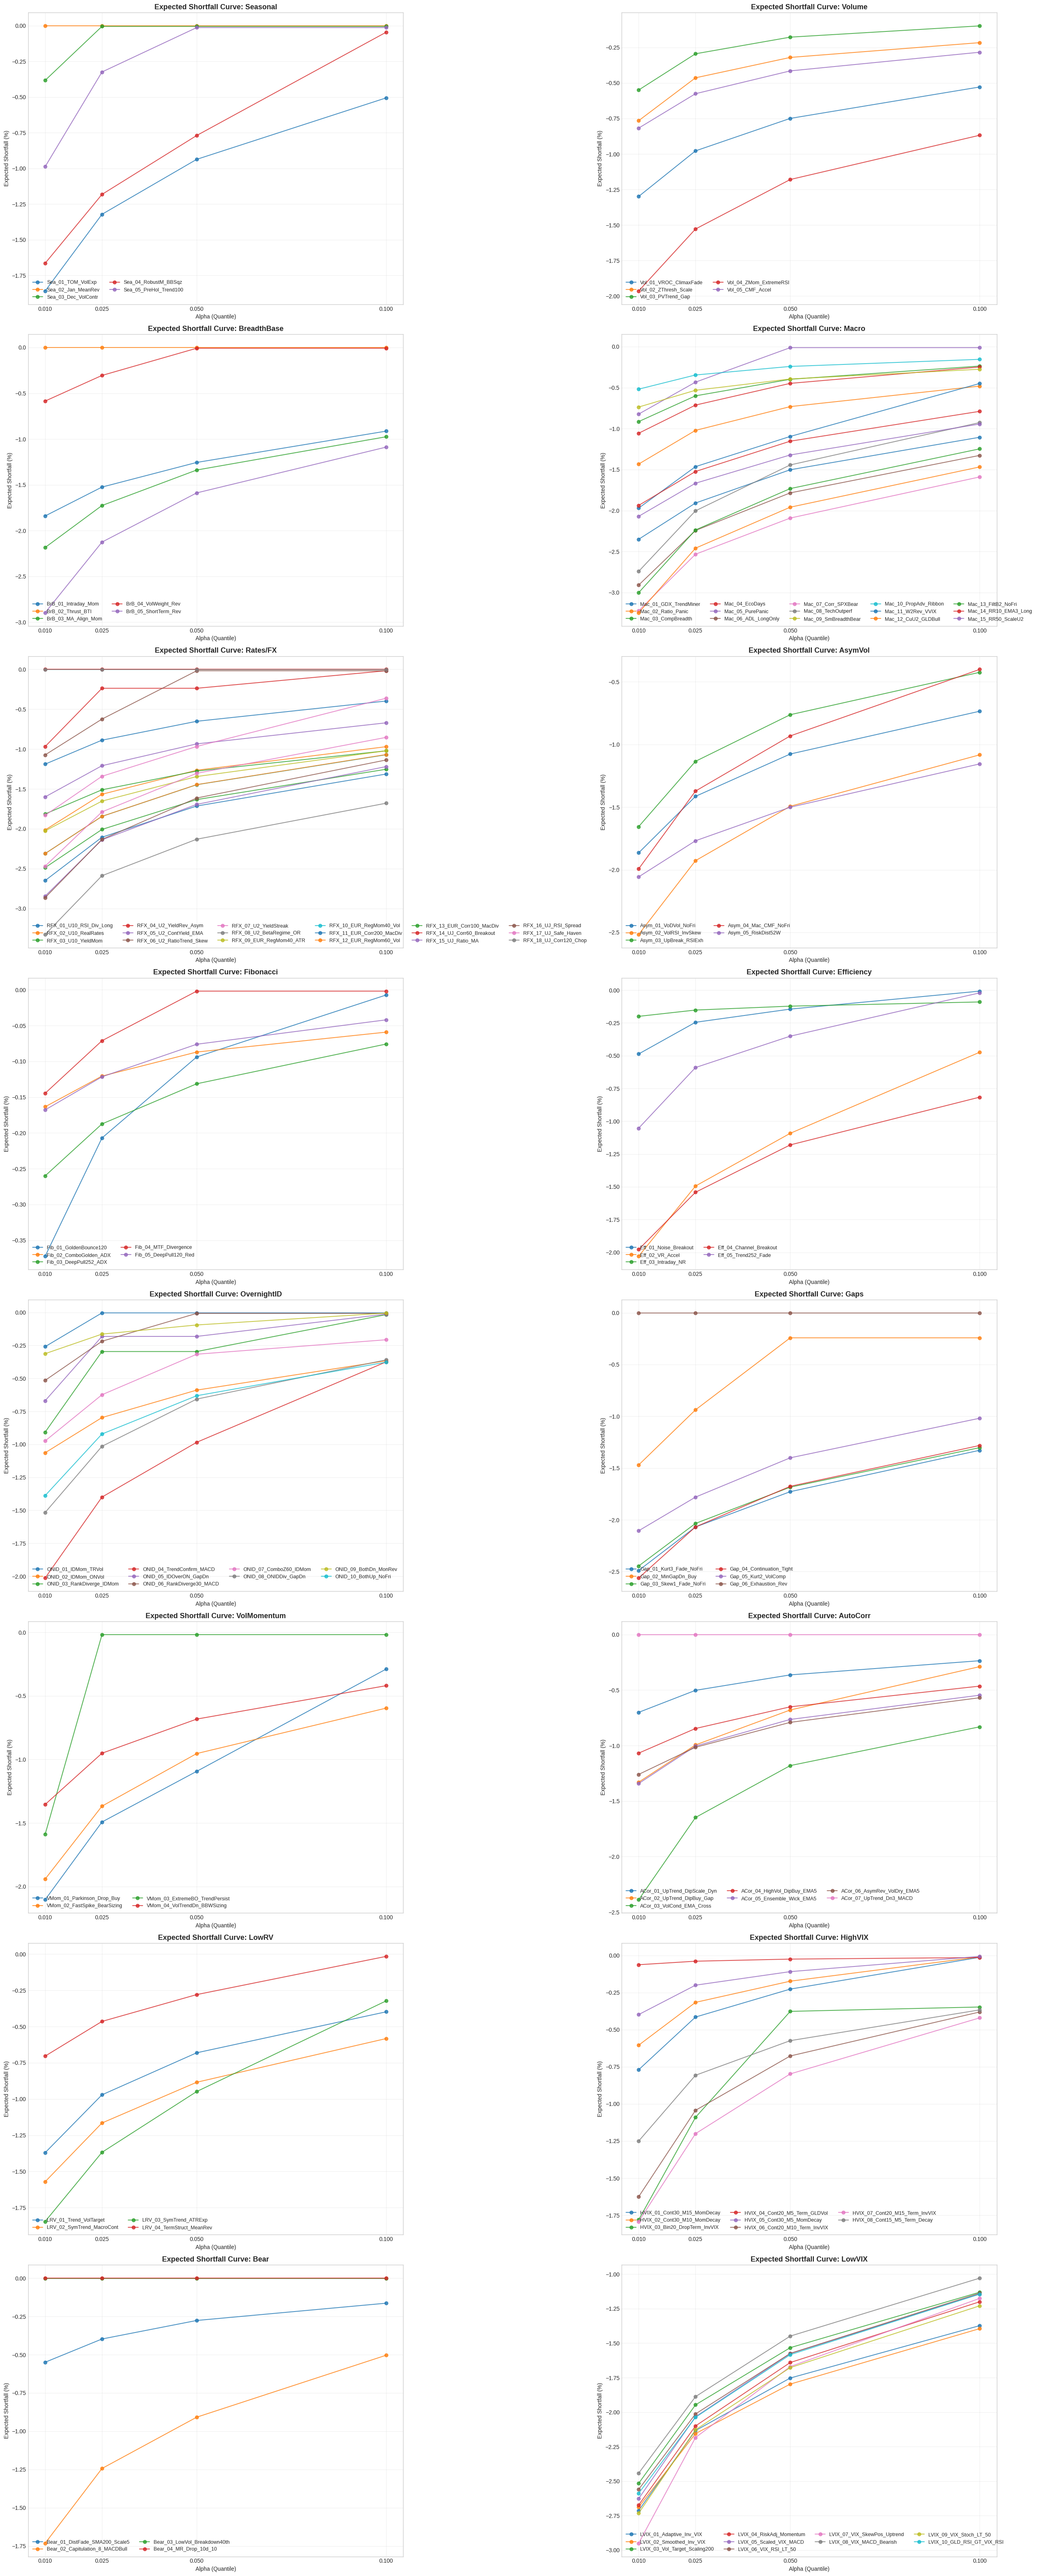


Generating Drawdown Duration Distributions...


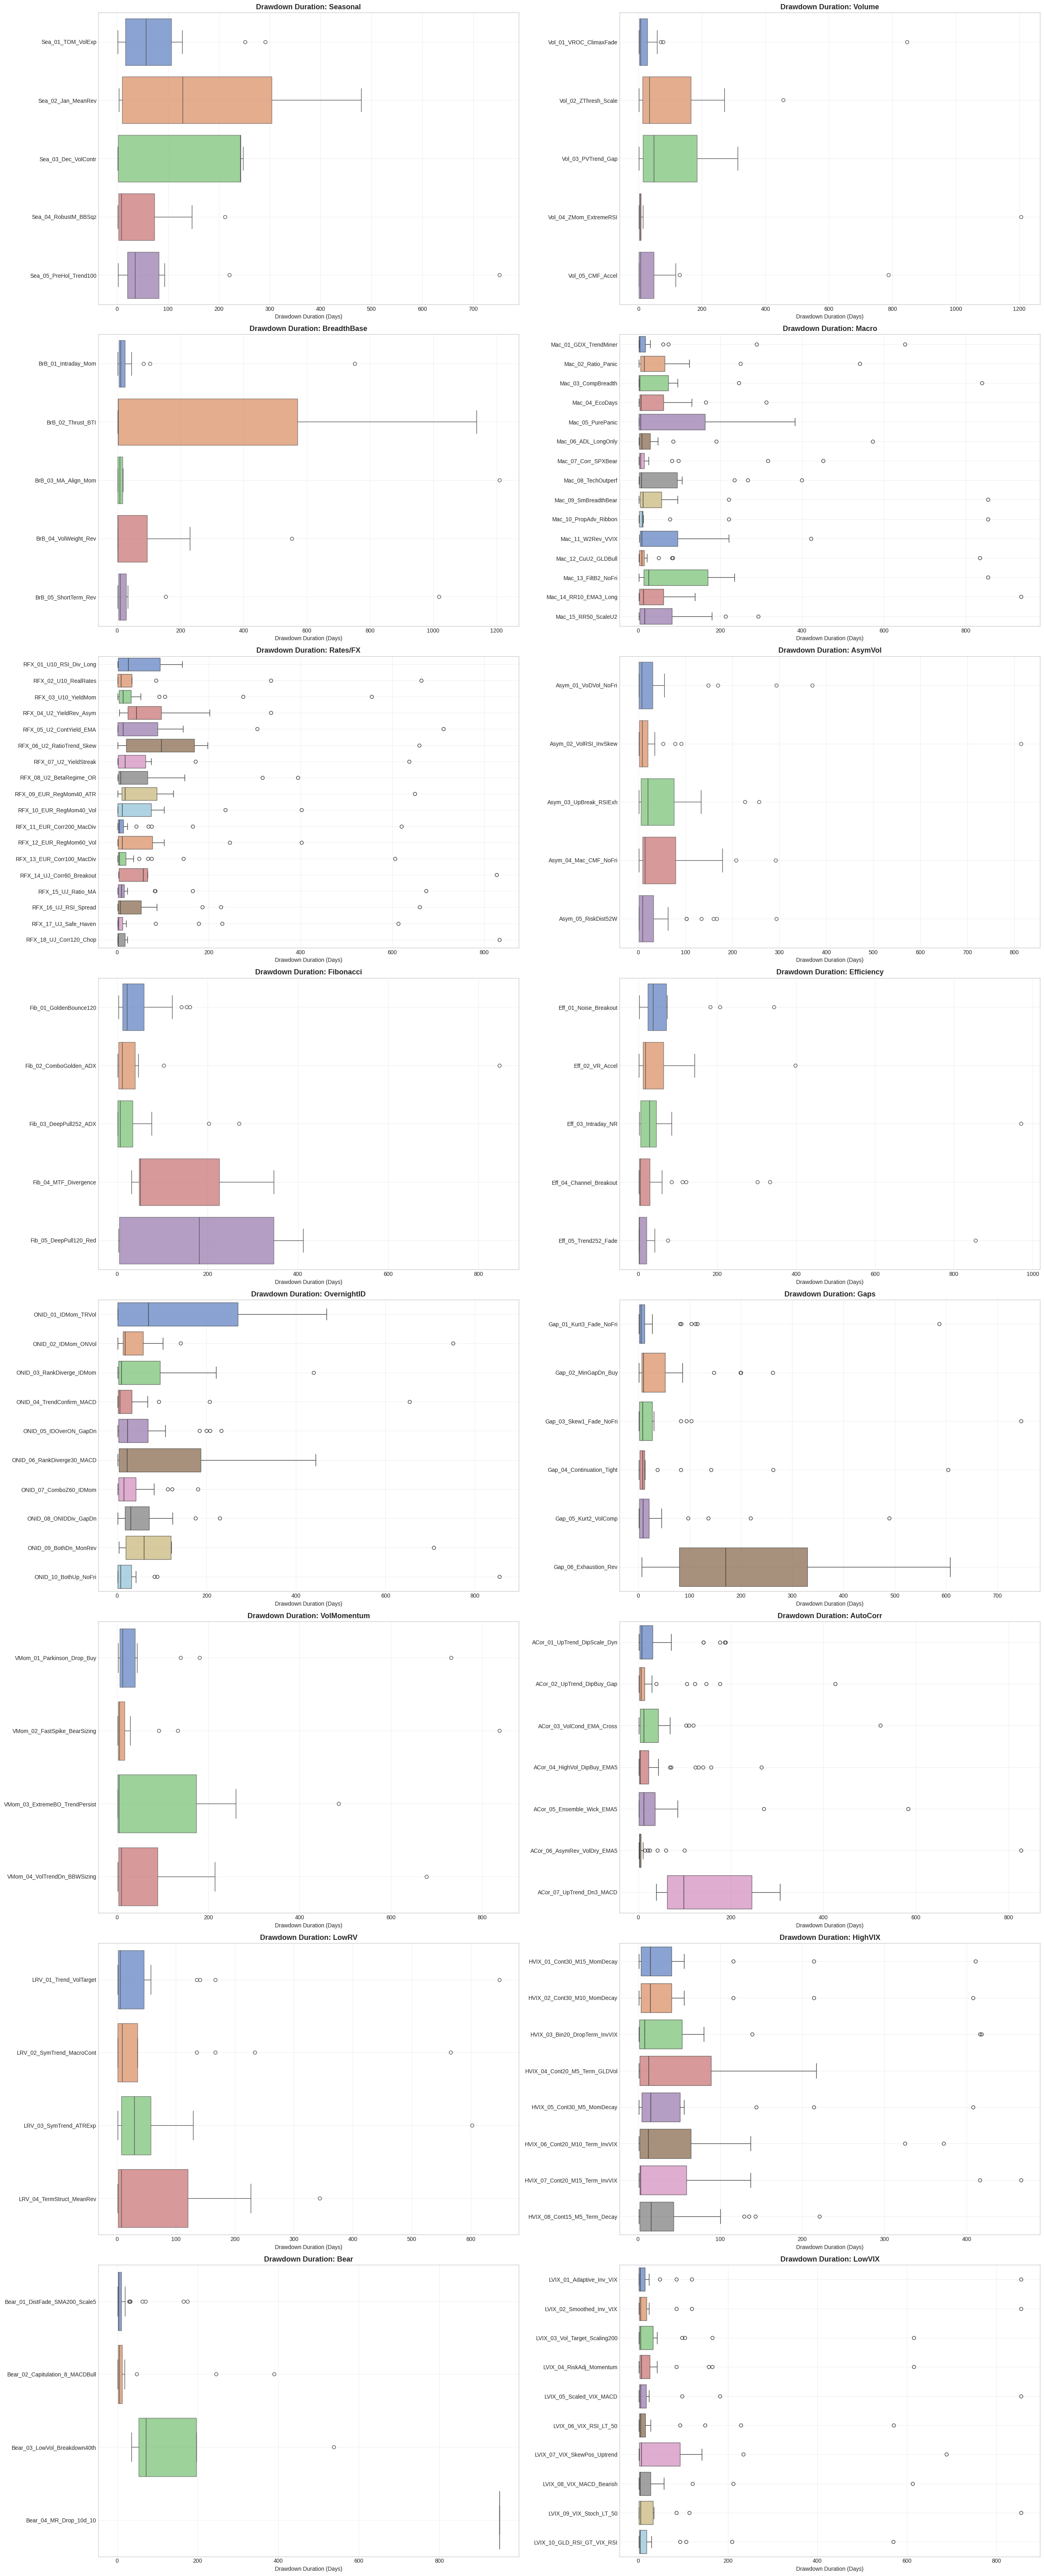

✅ Risk profile plotting complete. Proceed to Final Scorecard.


In [46]:
# ==============================================================================
# CELL 10: RISK PROFILES
# ==============================================================================
print("Plotting Risk Profiles for ALL Signals (Grouped by Family)...")

def calculate_dd_durations(ret: pd.Series) -> list:
    if len(ret) == 0: return[]
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    durations =[]
    d = 0
    for x in dd.values:
        if x < 0:
            d += 1
        elif d > 0:
            durations.append(d)
            d = 0
    if d > 0: durations.append(d)
    return durations

valid_groups = {grp: keys for grp, keys in SIG_GROUPS.items() if any(k in ALL_SIGS for k in keys)}
n_groups = len(valid_groups)

cols = 2
rows = math.ceil(n_groups / cols)

# ------------------------------------------------------------------------------
# PART 1: EXPECTED SHORTFALL CURVES
# ------------------------------------------------------------------------------
print("Generating Expected Shortfall Curves...")
fig1, axes1 = plt.subplots(rows, cols, figsize=(26, 8 * rows))
axes1 = axes1.flatten()

for idx, (grp, keys) in enumerate(valid_groups.items()):
    ax = axes1[idx]
    plot_count = 0

    for name in keys:
        if name not in ALL_SIGS: continue

        _, net, _, _ = compute_returns(ALL_SIGS[name], test_mask)
        r = net.fillna(0)

        es_vals =[]
        for a in ES_ALPHAS:
            tail = r[r <= np.quantile(r, a)]
            es = np.mean(tail) * 100 if len(tail) > 0 else 0.0
            es_vals.append(es)

        ax.plot(ES_ALPHAS, es_vals, marker="o", lw=1.5, alpha=0.8, label=name)
        plot_count += 1

    ax.set_title(f"Expected Shortfall Curve: {grp}", fontweight="bold", fontsize=13)
    ax.set_xlabel("Alpha (Quantile)")
    ax.set_ylabel("Expected Shortfall (%)")
    ax.set_xticks(ES_ALPHAS)

    if plot_count > 0:
        ax.legend(fontsize=9, ncol=max(1, math.ceil(plot_count / 3)), loc="lower left")

    ax.grid(True, alpha=0.3)

for i in range(n_groups, len(axes1)):
    fig1.delaxes(axes1[i])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# PART 2: DRAWDOWN DURATION DISTRIBUTIONS
# ------------------------------------------------------------------------------
print("\nGenerating Drawdown Duration Distributions...")
fig2, axes2 = plt.subplots(rows, cols, figsize=(26, 8 * rows))
axes2 = axes2.flatten()

for idx, (grp, keys) in enumerate(valid_groups.items()):
    ax = axes2[idx]
    dd_records =[]

    for name in keys:
        if name not in ALL_SIGS: continue

        _, net, _, _ = compute_returns(ALL_SIGS[name], test_mask)
        r = net.fillna(0)
        durs = calculate_dd_durations(r)

        for d in durs:
            dd_records.append({"Signal": name, "Duration": d})

    if dd_records:
        df_dd = pd.DataFrame(dd_records)
        sns.boxplot(data=df_dd, y="Signal", x="Duration", ax=ax,
                    palette="muted", boxprops=dict(alpha=0.7))
        ax.set_title(f"Drawdown Duration: {grp}", fontweight="bold", fontsize=13)
        ax.set_xlabel("Drawdown Duration (Days)")
        ax.set_ylabel("")
    else:
        ax.set_title(f"Drawdown Duration: {grp} (No Drawdowns)", fontweight="bold", fontsize=13)

    ax.grid(True, alpha=0.3)

for i in range(n_groups, len(axes2)):
    fig2.delaxes(axes2[i])

plt.tight_layout()
plt.show()

print("✅ Risk profile plotting complete. Proceed to Final Scorecard.")

# Research Quality Score With Gates

In [49]:
# ==============================================================================
# CELL 11: FINAL SCORECARD AND GATING
# ==============================================================================
print("Assembling Final Signal Leaderboard...")

def calculate_dd_durations(ret: pd.Series) -> list:
    if len(ret) == 0:
        return []
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    durations = []
    d = 0
    for x in dd.values:
        if x < 0:
            d += 1
        elif d > 0:
            durations.append(d)
            d = 0
    if d > 0:
        durations.append(d)
    return durations

def winsor_minmax_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    out = pd.Series(np.nan, index=s.index, dtype=float)

    if len(valid) == 0:
        return out

    lo, hi = np.nanpercentile(valid.values, [1, 99])
    clipped = s.clip(lower=lo, upper=hi)
    vmin = np.nanmin(clipped.values)
    vmax = np.nanmax(clipped.values)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or abs(vmax - vmin) < 1e-12:
        scaled = pd.Series(50.0, index=s.index)
    else:
        scaled = 100.0 * (clipped - vmin) / (vmax - vmin)

    if not higher_is_better:
        scaled = 100.0 - scaled

    out.loc[scaled.index] = scaled
    return out.clip(0, 100)

# ------------------------------------------------------------------------------
# PART 1: BUILD RAW LEADERBORD METRICS
# ------------------------------------------------------------------------------
rows = []
for name, sig in ALL_SIGS.items():
    te_m = base_metrics[name]["Test"]
    w_m = wfo_results.get(name, {})
    cpcv_m = cpcv_results.get(name, {})
    cscv_m = cscv_results.get(name, {})

    fdr_sig = False
    if "df_fdr" in globals() and name in df_fdr.index:
        fdr_sig = bool(df_fdr.loc[name].get("BH_significant", False))

    _, net, _, _ = compute_returns(sig, test_mask)
    r = net.fillna(0)
    durs = calculate_dd_durations(r)

    rows.append({
        "Signal": name,
        "Test_Sharpe": te_m.get("NetSharpe", np.nan),
        "Test_DSR": te_m.get("DSR", np.nan),
        "WFE_Median": w_m.get("WFE_Median", np.nan),
        "CPCV_MedianTestSharpe": cpcv_m.get("CPCV_MedianTestSharpe", np.nan),
        "Signal_PBO": cscv_m.get("Signal_PBO", np.nan),
        "Median_Rank_Ratio": cscv_m.get("Median_Rank_Ratio", np.nan),
        "Degradation": cscv_m.get("Degradation", np.nan),
        "BH_significant": fdr_sig,
        "TestMaxDD_Days": int(max(durs) if durs else 0),
        "ES": te_m.get("ES_5", np.nan)})

leaderboard = pd.DataFrame(rows).set_index("Signal")

lower_is_better = {"Signal_PBO", "Median_Rank_Ratio", "Degradation", "TestMaxDD_Days", "ES"}

metric_cfg = {
    "Test_Sharpe": True,
    "Test_DSR": True,
    "WFE_Median": True,
    "CPCV_MedianTestSharpe": True,
    "Signal_PBO": False,
    "Median_Rank_Ratio": False,
    "Degradation": False,
    "TestMaxDD_Days": False,
    "ES": False}

for col, hib in metric_cfg.items():
    leaderboard[f"SubScore_{col}"] = winsor_minmax_score(leaderboard[col], higher_is_better=hib)

leaderboard["SubScore_BH_significant"] = np.where(leaderboard["BH_significant"], 100.0, 0.0)

leaderboard["PBO_available"] = leaderboard["Signal_PBO"].notna()
leaderboard["Degradation_available"] = leaderboard["Degradation"].notna()

for c in ["Signal_PBO", "Degradation"]:
    sub = f"SubScore_{c}"
    median_sub = leaderboard.loc[leaderboard[c].notna(), sub].median()
    if not np.isfinite(median_sub):
        median_sub = 50.0
    leaderboard[sub] = leaderboard[sub].fillna(float(median_sub))

# ------------------------------------------------------------------------------
# PART 2: WEIGHTED SCORE & TABLES
# ------------------------------------------------------------------------------
weights = {
    "SubScore_Test_Sharpe": 15,
    "SubScore_CPCV_MedianTestSharpe": 15,
    "SubScore_WFE_Median": 10,
    "SubScore_Test_DSR": 15,
    "SubScore_BH_significant": 10,
    "SubScore_Signal_PBO": 10,
    "SubScore_Degradation": 10,
    "SubScore_ES": 5,
    "SubScore_TestMaxDD_Days": 5,
    "SubScore_Median_Rank_Ratio": 5}

weight_sum = float(sum(weights.values()))
leaderboard["TotalScore"] = 0.0
for col, w in weights.items():
    leaderboard["TotalScore"] += (w / weight_sum) * leaderboard[col]

leaderboard["Gate_TestSharpe"] = leaderboard["Test_Sharpe"] >= 0.5
leaderboard["Gate_CPCV"] = leaderboard["CPCV_MedianTestSharpe"] >= 0.0
leaderboard["Gate_DSR"] = leaderboard["Test_DSR"] >= 0.8
leaderboard["Gate_BH"] = leaderboard["BH_significant"]
leaderboard["Gate_DeployPass"] = (
    leaderboard["Gate_TestSharpe"]
    & leaderboard["Gate_CPCV"]
    & leaderboard["Gate_DSR"]
    & leaderboard["Gate_BH"])

q70 = leaderboard["TotalScore"].quantile(0.70)
q40 = leaderboard["TotalScore"].quantile(0.40)
leaderboard["FinalLabel"] = np.where(
    leaderboard["Gate_DeployPass"] & (leaderboard["TotalScore"] >= q70),
    "Deploy",
    np.where(leaderboard["TotalScore"] >= q40, "Monitor", "Research"))

leaderboard = leaderboard.sort_values("TotalScore", ascending=False)

gate_table_cols = ["TotalScore", "Gate_DeployPass", "FinalLabel"]
gate_table = leaderboard[gate_table_cols].copy()

detail_cols = [c for c in leaderboard.columns if c not in gate_table_cols]
detail_table = leaderboard[detail_cols].copy()

def style_with_direction(df: pd.DataFrame, lower_better_cols=None, caption=""):
    if lower_better_cols is None:
        lower_better_cols = []

    s = df.style.set_caption(caption)

    bool_cols = [c for c in df.columns if pd.api.types.is_bool_dtype(df[c])]
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in bool_cols]
    cat_cols = [c for c in df.columns if c not in num_cols and c not in bool_cols]

    lower_num = [c for c in num_cols if c in lower_better_cols]
    higher_num = [c for c in num_cols if c not in lower_num]

    if higher_num:
        s = s.background_gradient(cmap="RdYlGn", subset=higher_num)
    if lower_num:
        s = s.background_gradient(cmap="RdYlGn_r", subset=lower_num)

    def bool_color(v):
        if pd.isna(v):
            return "background-color:#f0f0f0;color:#666;"
        return "background-color:#c6efce;color:#006100;font-weight:600;" if bool(v) else "background-color:#ffc7ce;color:#9c0006;font-weight:600;"

    for c in bool_cols:
        s = s.map(bool_color, subset=[c])

    for c in cat_cols:
        if c == "FinalLabel":
            def label_color(v):
                if v == "Deploy":
                    return "background-color:#c6efce;color:#006100;font-weight:700;"
                if v == "Monitor":
                    return "background-color:#ffeb9c;color:#9c6500;font-weight:700;"
                if v == "Research":
                    return "background-color:#ffc7ce;color:#9c0006;font-weight:700;"
                return "background-color:#f7f7f7;color:#666;"
            s = s.map(label_color, subset=[c])
        else:
            s = s.map(lambda _: "background-color:#f7f7f7;", subset=[c])

    s = s.format(precision=3).set_properties(**{
        "border": "1px solid #ddd",
        "text-align": "center"})
    return s

detail_lower_cols = [c for c in lower_is_better if c in detail_table.columns]

print("\n✅ Final gate table:")
display(style_with_direction(gate_table, lower_better_cols=[], caption="Final Gate View"))

print("\n✅ Detail table:")
display(style_with_direction(detail_table, lower_better_cols=detail_lower_cols, caption="Detailed Metrics & Subscores"))

Assembling Final Signal Leaderboard...

✅ Final gate table:


,TotalScore,Gate_DeployPass,FinalLabel
Signal,,,
Sea_03_Dec_VolContr,63.021,False,Monitor
Fib_01_GoldenBounce120,60.197,False,Monitor
ONID_07_ComboZ60_IDMom,57.750,False,Monitor
RFX_01_U10_RSI_Div_Long,55.842,False,Monitor
Sea_04_RobustM_BBSqz,55.752,False,Monitor
Mac_05_PurePanic,55.174,False,Monitor
RFX_14_UJ_Corr60_Breakout,54.585,False,Monitor
BrB_04_VolWeight_Rev,52.509,False,Monitor
Eff_02_VR_Accel,50.587,False,Monitor



✅ Detail table:


,Test_Sharpe,Test_DSR,WFE_Median,CPCV_MedianTestSharpe,Signal_PBO,Median_Rank_Ratio,Degradation,BH_significant,TestMaxDD_Days,ES,SubScore_Test_Sharpe,SubScore_Test_DSR,SubScore_WFE_Median,SubScore_CPCV_MedianTestSharpe,SubScore_Signal_PBO,SubScore_Median_Rank_Ratio,SubScore_Degradation,SubScore_TestMaxDD_Days,SubScore_ES,SubScore_BH_significant,PBO_available,Degradation_available,Gate_TestSharpe,Gate_CPCV,Gate_DSR,Gate_BH
Signal,,,,,,,,,,,,,,,,,,,,,,,,,,
Sea_03_Dec_VolContr,1.365,0.914,0.140,0.663,0.581,0.909,0.715,False,248,-0.004,100.000,100.000,40.673,89.760,43.316,5.928,62.639,91.771,0.193,0.000,True,True,True,True,True,False
Fib_01_GoldenBounce120,1.345,0.954,0.712,0.538,1.000,0.698,0.713,False,161,-0.094,100.000,100.000,52.113,80.340,0.000,28.447,62.859,100.000,4.538,0.000,True,True,True,True,True,False
ONID_07_ComboZ60_IDMom,1.256,0.897,0.665,0.639,1.000,0.784,0.969,False,181,-0.317,95.202,98.396,51.183,87.964,0.000,19.256,37.566,98.265,15.305,0.000,True,True,True,True,True,False
RFX_01_U10_RSI_Div_Long,1.173,0.819,0.616,0.450,nan,0.659,nan,False,142,-0.651,89.938,89.815,50.194,73.750,0.000,32.583,45.970,100.000,31.431,0.000,False,False,True,True,True,False
Sea_04_RobustM_BBSqz,1.065,0.303,1.385,0.682,0.500,0.888,0.755,False,212,-0.769,83.099,33.205,65.588,91.166,51.738,8.226,58.683,95.260,37.128,0.000,True,True,True,True,False,False
Mac_05_PurePanic,0.873,0.003,0.867,0.802,0.000,0.974,0.311,False,383,-0.012,70.913,0.340,55.223,100.000,100.000,0.000,100.000,78.686,0.579,0.000,True,True,True,True,False,False
RFX_14_UJ_Corr60_Breakout,0.989,0.293,0.917,0.986,0.187,0.974,0.620,False,827,-0.000,78.285,32.118,56.224,100.000,84.161,0.000,72.033,35.650,0.000,0.000,True,True,True,True,False,False
BrB_04_VolWeight_Rev,1.205,0.726,1.370,0.375,nan,0.539,nan,False,552,-0.008,91.982,79.665,65.297,68.186,0.000,45.450,45.970,62.305,0.386,0.000,False,False,True,True,False,False
Eff_02_VR_Accel,0.813,0.000,1.022,0.637,0.333,0.888,0.569,False,398,-1.092,67.078,0.000,58.329,87.804,68.985,8.226,77.143,77.232,52.723,0.000,True,True,True,True,False,False
